# Comparativo de Algoritmos de Otimização

Neste notebook, vamos comparar o desempenho dos 4 algoritmos implementados:
1. **Hill Climbing**
2. **Simulated Annealing**
3. **Genetic Algorithm**
4. **Particle Swarm Optimization (PSO)**

Vamos testá-los em dois problemas clássicos de benchmark: **Sphere** (unimodal) e **Ackley** (multimodal).

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Adiciona o diretório raiz ao path para importar os módulos
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.problems import Sphere, Ackley
from src.hill_climbing import hill_climbing
from src.simulated_annealing import simulated_annealing
from src.genetic_algorithm import genetic_algorithm
from src.pso import particle_swarm_optimization

## Configuração do Experimento

Definiremos os parâmetros globais para garantir uma comparação justa:
- **Dimensões**: 10
- **Máximo de Avaliações**: 20.000 (para dar tempo de convergência)
- **Número de Execuções (Runs)**: 20 (para ter significância estatística)


In [2]:
# Parâmetros globais
N_VAR = 10
MAX_EVALS = 20000
N_RUNS = 20

# Dicionário para armazenar resultados
results = {
    "Algorithm": [],
    "Problem": [],
    "Run": [],
    "Best_Fitness": [],
    "History": []  # Armazena a curva de convergência de cada run
}

In [3]:
def run_experiment(problem_class, problem_name):
    print(f"Executing runs for {problem_name}...")
    
    for i in range(N_RUNS):
        # Instancia o problema
        problem = problem_class(n_var=N_VAR)
        
        # --- Hill Climbing --- 
        start_sol = np.random.uniform(problem.bounds[0], problem.bounds[1], N_VAR)
        _, best_val, hist = hill_climbing(problem, initial=start_sol, max_evals=MAX_EVALS, step_size=0.5, p=0.2)
        results["Algorithm"].append("Hill Climbing")
        results["Problem"].append(problem_name)
        results["Run"].append(i)
        results["Best_Fitness"].append(best_val)
        results["History"].append(hist)

        # --- Simulated Annealing --- 
        start_sol = np.random.uniform(problem.bounds[0], problem.bounds[1], N_VAR)
        _, best_val, hist = simulated_annealing(problem, initial=start_sol, max_evals=MAX_EVALS, step_size=1.0, cooling_rate=0.95)
        results["Algorithm"].append("Simulated Annealing")
        results["Problem"].append(problem_name)
        results["Run"].append(i)
        results["Best_Fitness"].append(best_val)
        results["History"].append(hist)

        # --- Genetic Algorithm --- 
        _, best_val, hist = genetic_algorithm(problem, popsize=50, n_elites=5, max_evals=MAX_EVALS)
        results["Algorithm"].append("Genetic Algorithm")
        results["Problem"].append(problem_name)
        results["Run"].append(i)
        results["Best_Fitness"].append(best_val)
        results["History"].append(hist)

        # --- PSO --- 
        _, best_val, hist = particle_swarm_optimization(problem, n_particles=30, max_evals=MAX_EVALS)
        results["Algorithm"].append("PSO")
        results["Problem"].append(problem_name)
        results["Run"].append(i)
        results["Best_Fitness"].append(best_val)
        results["History"].append(hist)

run_experiment(Sphere, "Sphere")
run_experiment(Ackley, "Ackley")

df_results = pd.DataFrame(results)
print("Experimento concluído!")

Executing runs for Sphere...
Executing runs for Ackley...
Experimento concluído!


## Análise dos Resultados Finais (Boxplot)
Vamos visualizar a distribuição do melhor valor encontrado por cada algoritmo após todas as iterações. Quanto menor (mais próximo de 0), melhor.

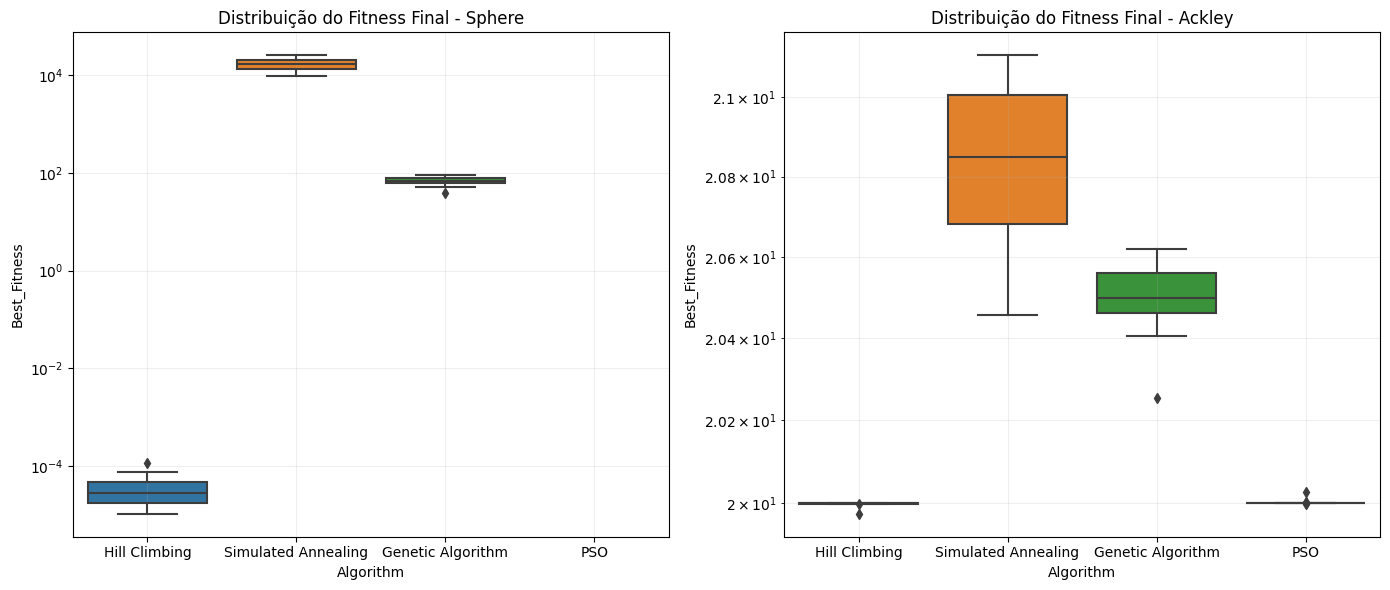

In [4]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x="Algorithm", y="Best_Fitness", data=df_results[df_results["Problem"] == "Sphere"])
plt.title("Distribuição do Fitness Final - Sphere")
plt.yscale("log") # Escala logarítmica ajuda a visualizar diferenças de magnitude
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.subplot(1, 2, 2)
sns.boxplot(x="Algorithm", y="Best_Fitness", data=df_results[df_results["Problem"] == "Ackley"])
plt.title("Distribuição do Fitness Final - Ackley")
plt.yscale("log")
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

## Análise de Convergência
Como os históricos têm tamanhos diferentes (alguns algoritmos salvam a cada melhoria, outros por geração), vamos normalizar para visualização ou pegar os dados brutos se possível. No caso dos nossos algoritmos:
- **HC & SA**: Salvam apenas quando há melhoria (histórico irregular).
- **GA & PSO**: Salvam por geração/iteração.

Para comparar, vamos plotar apenas o valor final médio, mas idealmente ajustaríamos para "melhor valor até a avaliação X".

In [5]:
# Tabela de resumo (Média e Desvio Padrão)
summary = df_results.groupby(["Problem", "Algorithm"])["Best_Fitness"].agg(["mean", "std", "min", "max"])
pd.options.display.float_format = '{:.6e}'.format
summary

mean          std          min  \
Problem Algorithm                                                    
Ackley  Genetic Algorithm   2.049700e+01 8.133340e-02 2.025467e+01   
        Hill Climbing       1.999846e+01 5.561063e-03 1.997492e+01   
        PSO                 2.000143e+01 5.958097e-03 1.999846e+01   
        Simulated Annealing 2.082055e+01 2.040574e-01 2.045737e+01   
Sphere  Genetic Algorithm   6.939896e+01 1.250180e+01 3.934793e+01   
        Hill Climbing       3.531849e-05 2.530948e-05 1.040350e-05   
        PSO                 0.000000e+00 0.000000e+00 0.000000e+00   
        Simulated Annealing 1.677117e+04 4.532739e+03 9.685265e+03   

                                     max  
Problem Algorithm                         
Ackley  Genetic Algorithm   2.062138e+01  
        Hill Climbing       2.000018e+01  
        PSO                 2.002644e+01  
        Simulated Annealing 2.110544e+01  
Sphere  Genetic Algorithm   9.224272e+01  
        Hill Climbing       1.115485e-04  
        PSO                 0.000000e+00  
        Simulated Annealing 2.566249e+04